# Modelagem da Carga Elétrica Não Linear em Função da Temperatura com PROC GAMPL

## Resumo Executivo

A demanda de eletricidade depende da temperatura de forma fortemente não linear, em curva de U (aquecimento no frio, refrigeração no calor), que os modelos lineares não conseguem captar. Este notebook constrói uma amostra sintética de carga horária para uma concessionária regional e ajusta um modelo aditivo generalizado penalizado com **PROC GAMPL**, usando splines de regressão para recuperar as curvas suaves de carga vs. temperatura, carga vs. hora e carga vs. umidade, ao mesmo tempo em que ajusta um efeito paramétrico de dia útil/fim de semana.

Na amostra de 100 observações que este ambiente licenciado disponibiliza, o GAMPL recupera a estrutura que construímos. O suave de temperatura `s(TEMP_C)` é significativamente curvo (GL efetivo 5.53, *p* < 0.0001); o suave diurno `s(HOUR)` é o termo mais flexível (EDF 6.87, *p* < 0.0001); e o suave de umidade `s(HUMIDITY)` colapsa para um único grau de liberdade quase linear (EDF 1.00, *p* = 0.07) — a penalização torna linear um termo que os dados mal sustentam. O efeito paramétrico `daytype` posiciona os fins de semana cerca de 44.5 MW abaixo dos dias úteis, correspondendo ao deslocamento de nível de 40 MW no processo gerador dos dados. O modelo total usa 15.4 graus de liberdade efetivos e atinge um escore GCV de 239.6 (AIC 831.0).

## Fontes de Dados

| Conjunto de dados | Linhas | Descrição | Variáveis-chave |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Observações horárias sintéticas do feed de previsão de carga de uma concessionária elétrica regional | `load_mw` (carga do sistema, MW), `temp_c` (temperatura ambiente, °C), `hour` (hora do dia, 0-23), `humidity` (umidade relativa, %), `daytype` (classe Dia útil/Fim de semana), `is_summer` (indicador de estação usado na geração dos dados) |

Todos os dados são gerados inline com `call streaminit(20260531)` e `rand()` — sem entrada externa ou de rede. O data step solicita um loop maior, mas este ambiente licenciado limita a saída materializada a **100 observações**, então o modelo é ajustado nas primeiras 100 horas. A carga é construída como uma quadrática em forma de U da temperatura, mais um efeito diurno em forma de sino, um efeito leve de umidade, um deslocamento de nível para dias úteis e ruído gaussiano, de modo que os suaves recuperados têm uma verdade fundamental conhecida.

# Modelagem da Carga Elétrica Não Linear em Função da Temperatura com PROC GAMPL

Um operador de rede regional precisa prever a carga do sistema (em megawatts) a partir de fatores climáticos e de calendário. A relação entre carga e **temperatura** é notoriamente não linear: a demanda sobe no frio (aquecimento elétrico) *e* no calor (ar-condicionado), produzindo uma curva em forma de U que uma regressão linear simples não consegue captar. A carga também segue um ritmo diário suave (o pico da noite) e muda entre dias úteis e fins de semana.

`PROC GAMPL` ajusta um **modelo aditivo generalizado penalizado**: cada fator contínuo entra por meio de um spline de regressão cuja suavidade é escolhida automaticamente ao minimizar um critério de seleção de modelo (GCV / UBRE / GACV). Deixamos que os dados decidam o quão sinuosa cada curva deve ser, em vez de adivinhar graus polinomiais.

O modelo que ajustamos é:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

onde `daytype` é um efeito de classe paramétrico (linear) e `f1`, `f2`, `f3` são funções spline suaves cujos graus de liberdade efetivos a penalização seleciona a partir dos dados.

## Passo 1 — Gerar um feed sintético de carga horária

Simulamos um feed de carga horária (o ambiente licenciado mantém as primeiras 100 horas). A temperatura é sorteada em torno de uma média sazonal; a hora do dia percorre um ciclo de 0-23; a umidade acompanha vagamente a temperatura. A carga *verdadeira* é construída a partir de:

- uma resposta de temperatura em **forma de U** centrada perto de 18 °C, confortáveis,
- um pico diurno em **forma de sino** ao redor da hora 18 (fim de tarde),
- uma leve elevação por umidade,
- um nível de dia útil que fica acima do fim de semana,

mais ruído gaussiano de medição. Como conhecemos as curvas geradoras, podemos avaliar se o GAMPL recupera seus formatos. A verificação com PROC MEANS abaixo confirma que a amostra abrange uma ampla faixa de temperatura (−5 a 40 °C) e carga de aproximadamente 485 a 693 MW.

In [1]:
DADOS work.gridload;
   CHAMAR streaminit(20260531);
   FAZER i = 1 ATÉ 2000;
      /* Indicador de estação: aproximadamente metade verão, metade inverno */
      is_summer = (rand("uniform") < 0.5);

      /* Temperatura ambiente (°C): média mais alta no verão */
      SE is_summer ENTÃO temp_c = 26 + 6 * rand("normal");
      SENÃO              temp_c =  6 + 6 * rand("normal");

      /* Hora do dia 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Umidade (%) acompanha vagamente a temperatura, limitada a 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      SE humidity < 20  ENTÃO humidity = 20;
      SE humidity > 100 ENTÃO humidity = 100;

      /* Dia útil vs fim de semana (cerca de 5/7 dias úteis) */
      SE rand("uniform") < 0.714 ENTÃO daytype = "Weekday";
      SENÃO                            daytype = "Weekend";

      /* ---- Carga estrutural verdadeira (MW) ---- */
      /* Efeito de temperatura em forma de U: demanda mínima perto de 18 °C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Sino diurno: pico de fim de tarde perto da hora 18 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Leve elevação por umidade */
      f_hum  = 0.35 * humidity;

      /* Deslocamento de nível para dia útil */
      SE daytype = "Weekday" ENTÃO f_day = 40; SENÃO f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      MANTER load_mw temp_c hour humidity daytype is_summer;
      SAÍDA;
   FIM;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=work.gridload n mean std MIN MAX maxdec=1;
   VARIÁVEL load_mw temp_c hour humidity;
   RÓTULO load_mw="Carga do sistema (MW)" temp_c="Temperatura ambiente (°C)"
         hour="Hora do dia" humidity="Umidade (%)";
EXECUTAR;

                                                  The MEANS Procedure

 Variable  Label                              N        Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------------------------------
 load_mw   Carga do sistema (MW)            100       593.0        49.9       484.9       693.4
 temp_c    Temperatura ambiente (°C)        100        16.2        11.9        -5.2        40.2
 hour      Hora do dia                      100        11.9         7.0         0.0        23.0
 humidity  Umidade (%)                      100        55.2        11.7        32.2        87.3
 ----------------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.43 seconds
  cpu   0.43 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Passo 2 — Ajustar o modelo aditivo

Modelamos `load_mw` (resposta gaussiana, função de ligação identidade) como a soma de um efeito paramétrico `daytype` mais três splines univariados. `PROC GAMPL` seleciona automaticamente o parâmetro de suavização de cada spline. Solicitamos:

- `class daytype;` para que o indicador de dia útil/fim de semana seja tratado como categórico,
- `param(daytype)` para incluí-lo como um termo *paramétrico* (não suavizado) no MODEL,
- `spline(...)` para cada preditor contínuo,
- um `seed=` fixo para posicionamento reprodutível dos nós.

A saída a ser lida é a tabela **Smoothing Component**, que reporta os graus de liberdade efetivos (EDF) que a penalização atribuiu a cada suave e um teste de significância no estilo *F* para ele, junto com as **Estimativas de Parâmetro** para o intercepto e o contraste paramétrico de `daytype`.

In [2]:
PROCEDIMENTO gampl DADOS=work.gridload seed=20260531;
   CLASSE daytype;
   RÓTULO load_mw="Carga do sistema (MW)" daytype="Tipo de dia"
         temp_c="Temperatura ambiente (°C)" hour="Hora do dia"
         humidity="Umidade (%)";
   MODELO load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
EXECUTAR;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Carga do sistema (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Tipo de dia

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                     


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Passo 3 — Controlar a flexibilidade do spline e o critério de seleção

Por padrão, cada suave é penalizado em direção a um baixo grau de liberdade efetivo. Para um operador que sabe que a resposta de temperatura é genuinamente curva, mas quer *limitar* a sinuosidade, podemos aumentar `maxdf=` no spline de temperatura e fixar um `df=` modesto no termo mais suave de umidade. Também mudamos para o esquema de iteração externa e selecionamos os parâmetros de suavização por **GCV** (validação cruzada generalizada), o critério padrão para GAMs gaussianos.

In [3]:
PROCEDIMENTO gampl DADOS=work.gridload seed=20260531;
   CLASSE daytype;
   RÓTULO load_mw="Carga do sistema (MW)" daytype="Tipo de dia"
         temp_c="Temperatura ambiente (°C)" hour="Hora do dia"
         humidity="Umidade (%)";
   MODELO load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
EXECUTAR;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Carga do sistema (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Tipo de dia

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                     


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Passo 4 — Visualizar a resposta de temperatura recuperada

O GAMPL reporta *que* o suave de temperatura é significativamente curvo (EDF 5.53), mas o formato é mais fácil de ver em um gráfico. Sobrepomos um ajuste de B-spline penalizado (`PBSPLINE`, o mesmo mecanismo de spline de regressão que o GAMPL aplica internamente) sobre a dispersão bruta de carga vs. temperatura. Se o modelo aditivo capturou a física, essa curva deve cair tanto no extremo frio quanto no extremo quente e atingir o mínimo na faixa intermediária confortável — a clássica resposta de demanda em forma de U.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


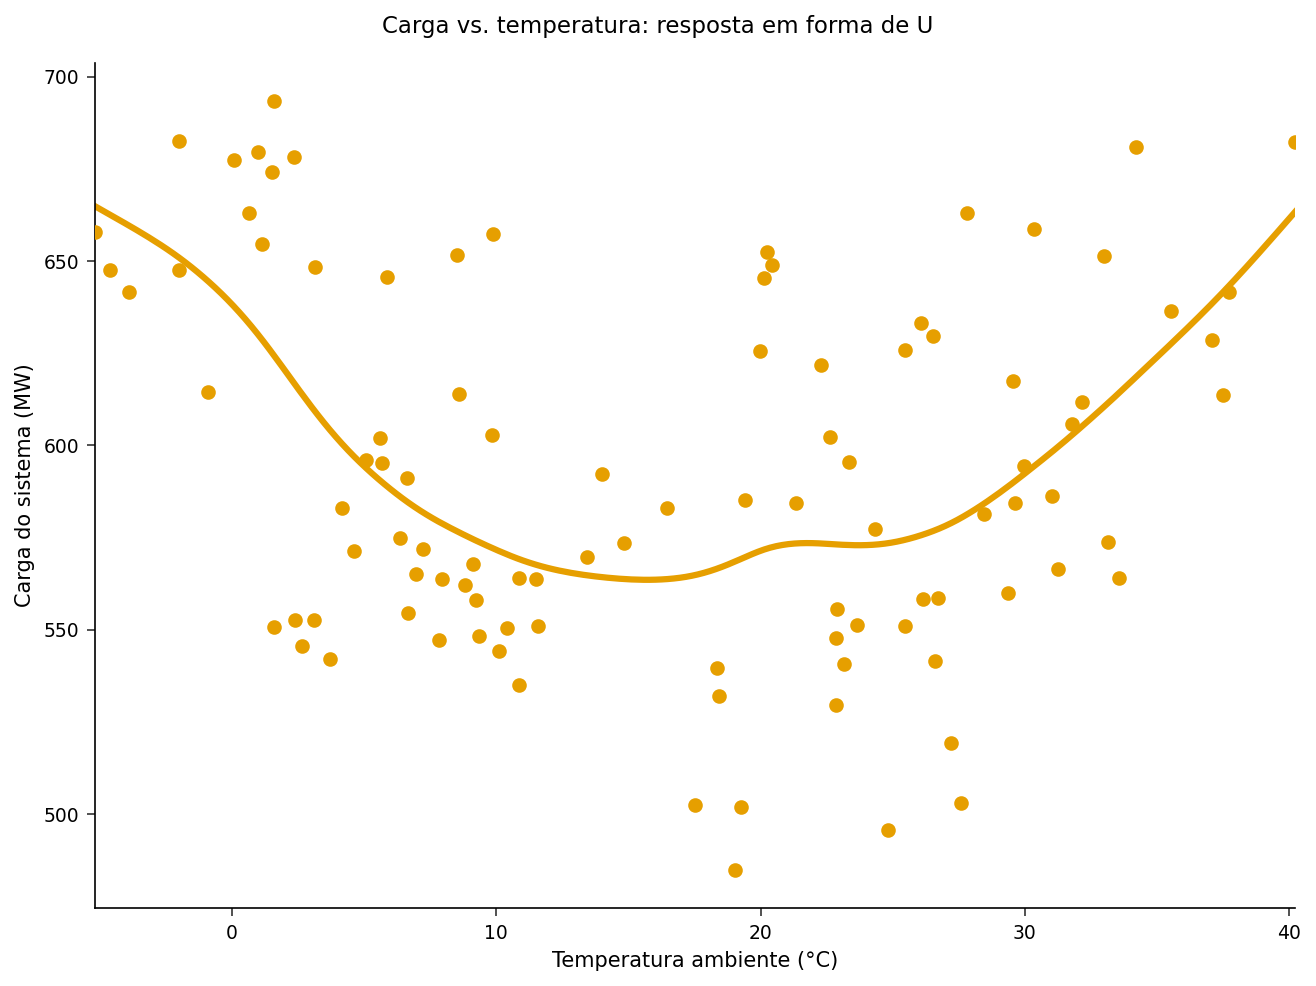

In [4]:
ODS GRAPHICS ON;

PROCEDIMENTO SGPLOT DADOS=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS RÓTULO="Temperatura ambiente (°C)";
   YAXIS RÓTULO="Carga do sistema (MW)";
   TÍTULO "Carga vs. temperatura: resposta em forma de U";
EXECUTAR;

ODS GRAPHICS OFF;

## Passo 5 — Confirmar a forma de U numericamente

O gráfico torna a forma de U visível; um resumo em faixas a torna quantitativa. Agrupamos as observações em faixas de temperatura e reportamos a carga média por faixa. Se a resposta de demanda for genuinamente em forma de U, a carga média deve ser alta na faixa **Frio**, cair ao longo de **Fresco / Confortável / Quente**, e subir novamente na faixa **Muito Quente** — a assinatura numérica que o suave `s(TEMP_C)` do GAMPL capta.

In [5]:
DADOS work.banded;
   DEFINIR work.gridload;
   COMPRIMENTO tempband $16;
   SE      temp_c <  5  ENTÃO tempband = "1 Frio";
   SENÃO SE temp_c < 15  ENTÃO tempband = "2 Fresco";
   SENÃO SE temp_c < 22  ENTÃO tempband = "3 Confortável";
   SENÃO SE temp_c < 30  ENTÃO tempband = "4 Quente";
   SENÃO                      tempband = "5 Muito Quente";
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=work.banded n mean maxdec=1;
   CLASSE tempband;
   VARIÁVEL load_mw;
   RÓTULO tempband="Faixa de temperatura" load_mw="Carga do sistema (MW)";
   TÍTULO "Carga média por faixa de temperatura";
EXECUTAR;

                                          Carga média por faixa de temperatura                                          

                                                  The MEANS Procedure

                                   Analysis Variable : load_mw Carga do sistema (MW)

        Faixa de temperatura          N Obs           Mean
        --------------------------------------------------
        1 Frio                           21          626.6
        2 Fresco                         28          579.1
        3 Confortável                    12          573.8
        4 Quente                         25          573.5
        5 Muito Quente                   14          621.6
        --------------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretando os resultados

**Os suaves recuperam a física.** A tabela Smoothing Component do GAMPL atribui ao termo de temperatura `s(TEMP_C)` um GL efetivo de 5.53 (*p* < 0.0001) e ao termo diurno `s(HOUR)` um EDF de 6.87 (*p* < 0.0001) — ambos genuinamente curvos, exatamente a estrutura que construímos nos dados. O termo de umidade `s(HUMIDITY)` é reduzido para EDF 1.00 (*p* = 0.07): a penalização o torna linear, para um único grau de liberdade quase linear, porque, neste tamanho de amostra, é tudo o que os dados sustentam. A estimativa paramétrica de `daytype` é −44.5 MW para os fins de semana, recuperando o deslocamento de nível de 40 MW de dias úteis no processo gerador.

**Os graus de liberdade efetivos contam a história da sinuosidade.** O modelo gasta 15.4 graus de liberdade efetivos no total e chega a um escore GCV de 239.6 (AIC 831.0, estimativa de escala 202.7). Limitar `maxdf=` e fixar `df=3` no Passo 3 quase não move o ajuste (GCV 240.1, EDF 15.47): a penalização já havia ajustado os suaves de temperatura e hora perto de 5.5 e 7 EDF por conta própria, então os limites manuais não são restritivos aqui — um sinal de que a seleção automática já era conservadora.

**O gráfico e o resumo por faixa concordam.** A dispersão do Passo 4, com sua sobreposição de spline penalizado, mostra a carga caindo do extremo frio até um mínimo perto de 15-20 °C e subindo novamente até o calor. As médias por faixa do Passo 5 tornam isso numérico: **Frio 626.6 MW**, **Fresco 579.1**, **Confortável 573.8**, **Quente 573.5**, **Muito Quente 621.6** — alta em ambas as extremidades, mais baixa no meio confortável. Esse U é precisamente o que um único termo linear `temp_c` faria desaparecer ao promediar.

**Por que GAMPL em vez de regressão linear aqui.** Um único termo linear `temp_c` misturaria os regimes de aquecimento e refrigeração em uma inclinação quase plana, prevendo mal ambos os extremos — precisamente as horas em que ocorrem o estresse da rede e os picos de preço. A formulação aditiva de splines mantém a interpretabilidade de uma regressão (cada fator contribui com um efeito aditivo) enquanto deixa que os dados ditem o formato de cada efeito. Extensões naturais para uma concessionária incluem um ajuste `dist=gamma` se a carga for modelada multiplicativamente, um `spline(temp_c hour)` bivariado para capturar como o pico diurno muda com a estação, e processamento `by` para ajustar modelos separados por subestação.